# Designing Filters With Windows

## Desirable Properties of a filter

1. Steep stop-band attenuation: the filter effectively removes frequency content where it is intended
2. Negligible passband ripple: the frequencies that are not attenuated have no distortion effects 
3. Narrow transition band: the filter efficiently moves from the pass band to the stop band 

There is always a trade-off between these properties. The order of the filter determines the performance. However,  its interactions with other factors can be complex, making the design process particularly challenging.

## FIR Design Through Windowing

We covered the theory behind FIR filter design using the window method [here](https://ringbuffer.org/dsp/Digital_Filters/fir_design_windowing). Today, we'll use the SciPy package and its `scipy.signal.firwin` function to filter audio-rate signals.



In [8]:
import numpy as np
from scipy.signal import firwin, freqz, convolve
import matplotlib.pyplot as plt
import IPython.display as ipd
from scipy.io import wavfile

### Generating A Chirp Signal

In [9]:
from scipy.signal import chirp

# Parameters
duration = 5.0     
fs = 48000          
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

f0 = 100 
f1 = 10000            
# Generate ascending (linear chirp) sine tone
tone = chirp(t, f0=f0, t1=duration, f1=f1, method='linear')

# Save the tone as a WAV file (optional)
wavfile.write("ascending_sine_tone.wav", fs, tone.astype(np.float32))

### Low Pass Filtering using FIRWIN

In [11]:
x = tone

fs = 48000
f_cutoff = 700 # In Hz

# Ensuring the impulse response widnow is as long as two cycles of the cutoff 
order = 2 * fs // f_cutoff + 1

# Convert the cutoff frequency to a normalized frequency (0 to 1, where 1 is the Nyquist frequency)
norm_cutoff = f_cutoff / (fs / 2)


# Build the filter
hw = firwin(order, norm_cutoff, window='hann')

# Apply the filter to a signal
y1 = convolve(x, hw, mode='same')

#### Unfiltered Audio

In [12]:
ipd.Audio(tone, rate=fs)

#### Filtered Audio

In [13]:
ipd.Audio(y1, rate=fs)

### Function To Visualize the response of the filter

In [14]:
def visualize_filter(impulse_response):
    
    w, h = freqz(impulse_response)
    magnitude_dB = 20 * np.log10(np.abs(h))
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(131)
    plt.plot(impulse_response)
    plt.title('Impulse Response')
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")

    # Logarithmic Magnitude Response (in dB)
    plt.subplot(132)
    plt.plot(w/np.pi, magnitude_dB)
    plt.title("Magnitude Response (dB)")
    plt.xlabel("Normalized Frequency")
    plt.ylabel("Magnitude (dB)")
    plt.grid(True)

    # Phase Response
    plt.subplot(133)
    plt.plot(w/np.pi, np.unwrap(np.angle(h)))
    plt.title("Phase Response")
    plt.xlabel("Normalized Frequency")
    plt.ylabel("Phase (radians)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


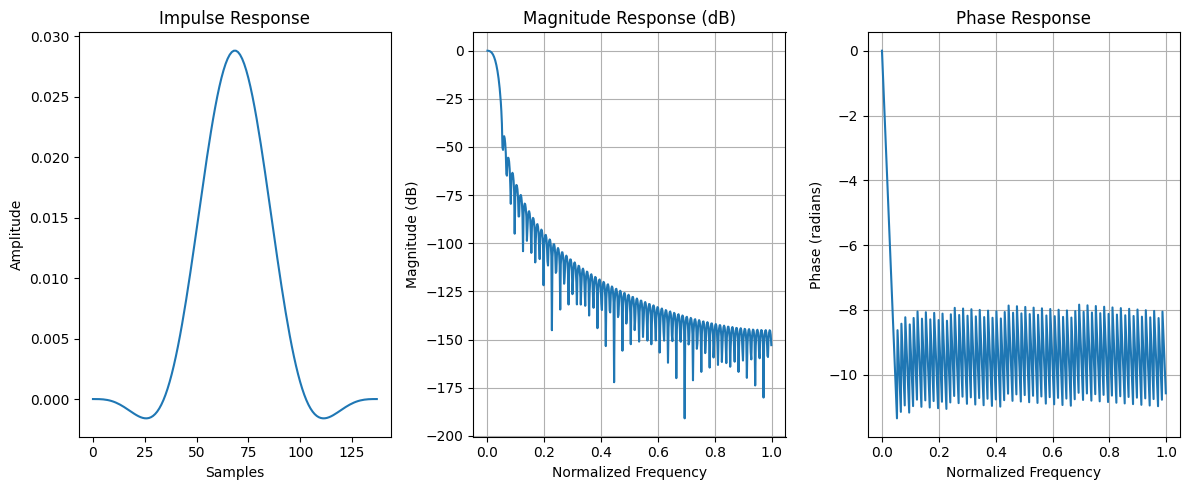

In [16]:
visualize_filter(hw)

### High pass filtering using FIRWIN

In [17]:
x = tone
# Filter parameters
f_cutoff = 12000    # Cutoff frequency in Hz

# Determine filter length: ensure the impulse response is as long as two cycles of the cutoff frequency.
order = 32 * fs // f_cutoff  +1  # This will be 2*48000//400 = 240 taps


norm_cutoff = f_cutoff / (fs)


hw2 = firwin(order, norm_cutoff, window='hann', pass_zero=False)

# Apply the filter using convolution
y2 = convolve(x, hw2, mode='same')

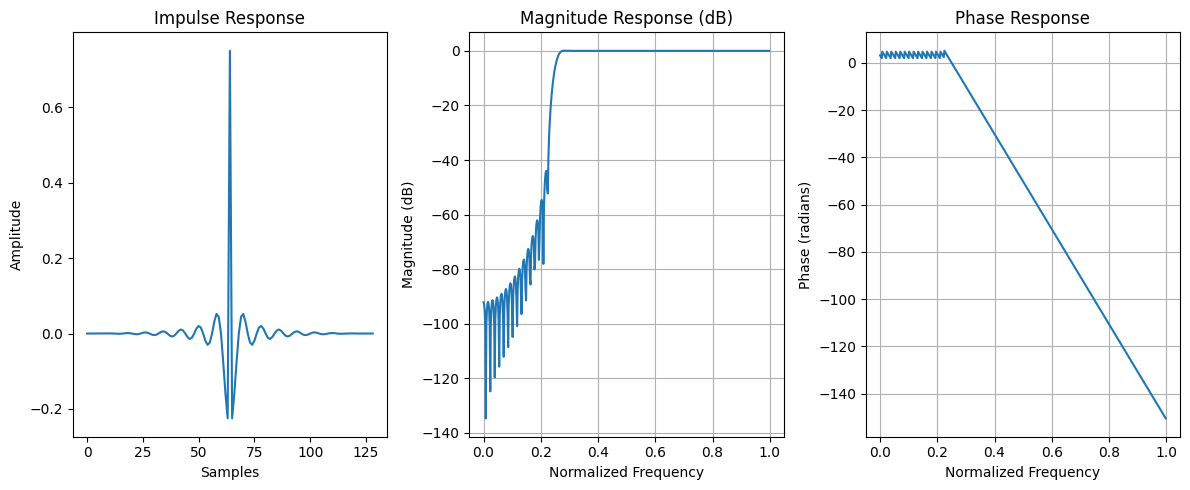

In [18]:
visualize_filter(hw2)

#### Unfiltered Audio

In [19]:
ipd.Audio(tone, rate=fs)

#### Filtered Audio

In [20]:
ipd.Audio(y2, rate=fs)

### Band pass filtering using firwin

In [22]:
x = tone

low_cut = 1000         # Lower cutoff frequency in Hz
high_cut = 2000       # Upper cutoff frequency in Hz

# Determine filter length: ensure the impulse response is as long as two cycles of the high-cutoff frequency.
order = 8 * fs // high_cut  + 1 

# Normalize the cutoff frequencies
norm_low = low_cut / (fs/2)
norm_high = high_cut / (fs/2)

# Design a bandpass filter: pass frequencies between norm_low and norm_high.
hw3 = firwin(order, [norm_low, norm_high], pass_zero=False)

# Apply the filter using convolution
y3 = convolve(x, hw3, mode='same')

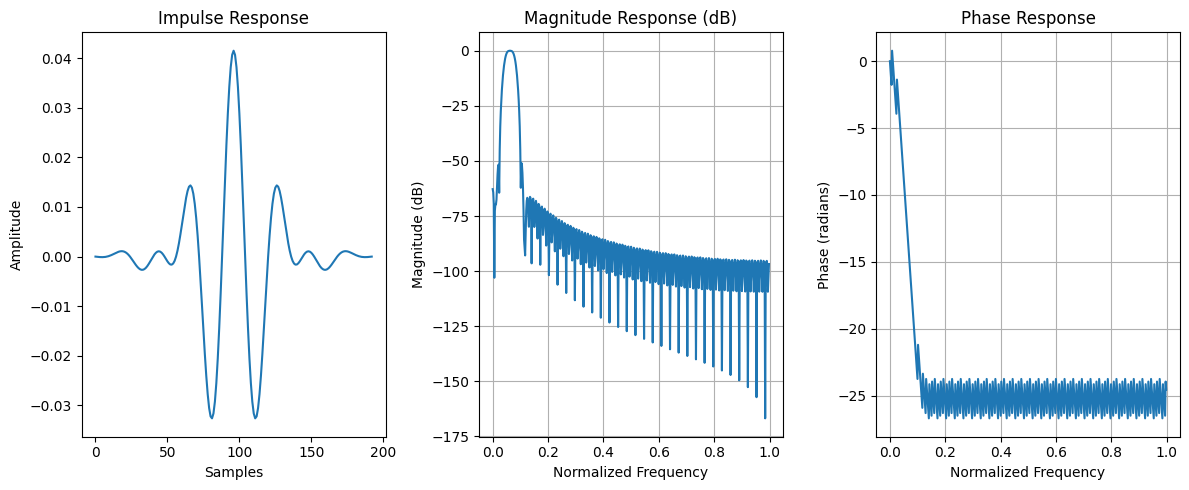

In [24]:
visualize_filter(hw3)

#### Unfiltered Audio

In [25]:
ipd.Audio(tone, rate=fs)

#### Filtered Audio

In [26]:
ipd.Audio(y3, rate=fs)

# Activity

Design your own filters using the window method! Set your own parameters:
1. Cut Off Frequency
2. Use Different Window Functions
2. Filter Order 
3. Type Of Filter (High Pass, Low Pass, BandPass, BandStop)

Visualize the filters, Use any audio signal you want and try to filter out the noise or undesirable parts

### Activity Steps
Using the below defined functions
1. Load Your Audio Signal 
2. Design the filter using any specified characteristics
3. Save your filtered audio signal
4. Visualize the frequency response of the filter

In [27]:
def load_audio_signal(path):

    # Read the WAV file
    fs, data = wavfile.read(path)
    
    # If stereo, convert to mono by averaging channels
    if data.ndim > 1:
        data = data.mean(axis=1)
    
    # Optionally, normalize the signal to range [-1, 1] if the dtype is integer
    if np.issubdtype(data.dtype, np.integer):
        max_val = np.iinfo(data.dtype).max
        data = data / max_val
    
    return data, fs
    

In [40]:
def filter_design(fs, order_magnitude, cutoff, window_str, isPass):
    """
    Design an FIR filter using firwin.

    Parameters:
        fs (int or float): Sampling frequency in Hz.
        order_magnitude (int): A multiplier used to determine filter length.
        cutoff (float or list/tuple of two floats):
            - If a single number, it is the cutoff frequency in Hz.
            - If an array-like of two numbers, [low_cut, high_cut] defines the band.
        window_str - The window function name (e.g., 'hann', 'hamming', etc.).
        isPass (bool):
            - For a single cutoff:
                * True  -> lowpass filter (pass frequencies below cutoff)
                * False -> stop filter (stops frequencies until cutoff)
    
    Returns:
        hw (ndarray): The designed FIR filter coefficients.
    """
    import numpy as np
    from scipy.signal import firwin

    # Check if cutoff is array-like with two elements.
    if isinstance(cutoff, (list, tuple, np.ndarray)) and len(cutoff) == 2:
        # For a band filter, use the upper cutoff for computing filter length.
        high_cut = max(cutoff)
        order = order_magnitude * fs // high_cut + 1
        
        # Normalize both cutoff frequencies (Nyquist frequency is fs/2)
        norm_low = cutoff[0] / (fs / 2)
        norm_high = cutoff[1] / (fs / 2)
        
        # Design a bandpass filter (pass frequencies between norm_low and norm_high)
        hw = firwin(order, [norm_low, norm_high], window = window_str, pass_zero=isPass)
        
    else:
        # Single cutoff frequency.
        order = order_magnitude * fs // cutoff + 1
        norm_cutoff = cutoff / (fs / 2)
        # For a lowpass filter, we want pass_zero=True; for a highpass filter, pass_zero=False.
        hw = firwin(order, norm_cutoff, window = window_str, pass_zero=isPass)

    return hw

#### Windows to try:

- **boxcar**
- **triang**
- **blackman**
- **hamming**
- **hann**
- **blackmanharris**


In [43]:
def filter_signal(audio,impulse_response):
    return convolve(audio, impulse_response, mode='same')

#### Example

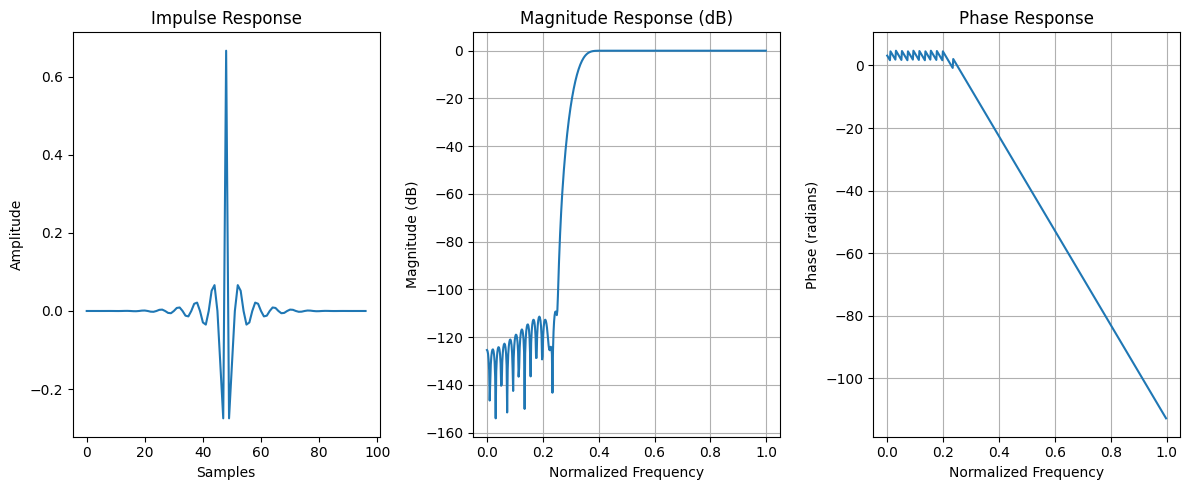

In [52]:
audio,fs = load_audio_signal("ascending_sine_tone.wav")

impulse_response = filter_design(fs, 16 , 8000, 'blackmanharris', False)

y_out = filter_signal(audio,impulse_response)

wavfile.write("filtered_audio.wav", fs, tone.astype(np.float32))

visualize_filter(impulse_response)

In [53]:
ipd.Audio(y3, rate=fs)

## Parks-McCellan method/ Remez

Scipy allows you to design filters that will attempt to minimize the ripple in both the pass and stop bands, using the Parks-McCellan or Remez method

You have to explicity describe the transition band, and desired gain in each band in this design

In [94]:
f_cutoff = 500

# One cycle of the cutoff frequency
order = fs // f_cutoff

# Build the filter using the Remez method

#    Pass band: [0, 0.75 * f_cutoff]  (begin to transition at 75% of our cutoff)
#          gain: 1

#    Stop band: [f_cutoff, fs/2]  (attenuate everything above the cutoff)
#          gain: 0

hpm = scipy.signal.remez(order, 
                             [0, 0.75 * f_cutoff, f_cutoff, fs/2],  # Our frequency bands
                             [1, 0],  # Our target gain for each band
                             fs=fs)

# Apply the filter to a signal
y = scipy.signal.convolve(x, hpm)

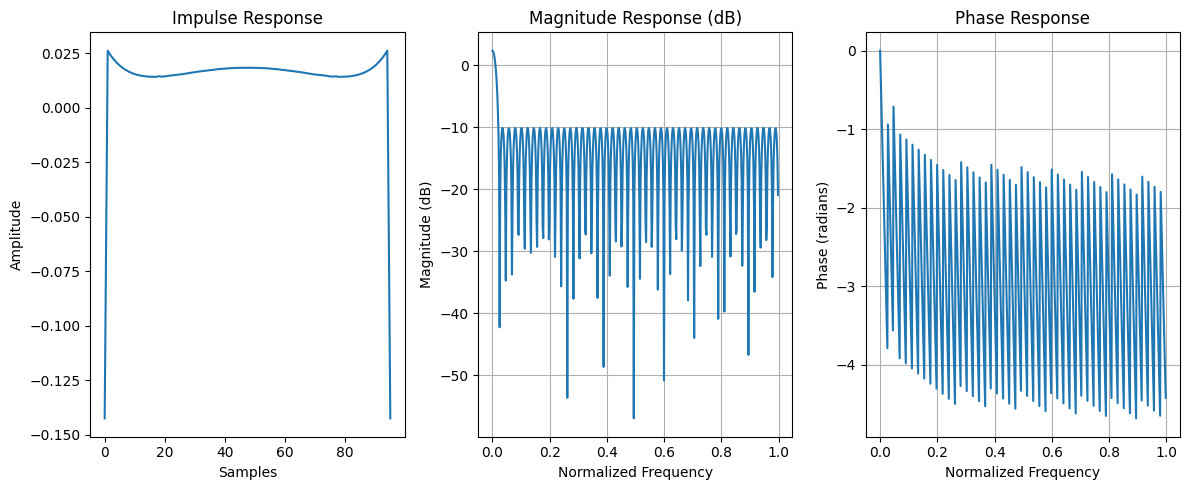

In [95]:
visualize_filter(hpm)